## Practical Task 1 — Train a Word2Vec Model

### 1. Create a small text dataset

In [ ]:
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

corpus = [
    'natural language processing helps computers understand human language',
    'machine learning models learn patterns from large datasets',
    'deep learning uses neural networks with many hidden layers',
    'word embeddings represent words as dense numerical vectors',
    'text classification assigns categories to documents using machine learning',
    'sentiment analysis determines the emotional tone of a sentence',
    'neural networks are inspired by the structure of the human brain',
    'transformers are powerful models used in modern natural language processing',
    'tokenization splits text into individual words or tokens',
    'word2vec trains word embeddings using a shallow neural network',
    'glove learns word vectors by factorizing a word co-occurrence matrix',
    'fasttext extends word2vec by representing words as character n-grams',
    'training a model requires a large annotated dataset',
    'language models predict the next word given a sequence of words',
    'named entity recognition identifies people places and organizations in text',
    'part of speech tagging labels each word with its grammatical role',
    'recurrent neural networks process sequences of text step by step',
    'attention mechanisms allow models to focus on relevant parts of the input',
    'stopword removal filters out common words that carry little meaning',
    'lemmatization reduces words to their base or root form'
]

tokenized_corpus = [simple_preprocess(sentence) for sentence in corpus]

print(f'Corpus size: {len(tokenized_corpus)} sentences')
print(f'Sample tokens: {tokenized_corpus[0]}')

Corpus size: 20 sentences
Sample tokens: ['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'human', 'language']


### 2. Train a Word2Vec model

In [2]:
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=200,
    seed=42
)

vocab = list(model.wv.key_to_index.keys())
print(f'Vocabulary size    : {len(vocab)} unique words')
print(f'Embedding dimensions: {model.vector_size}')

Vocabulary size    : 129 unique words
Embedding dimensions: 100


### 3. Display word vectors

In [3]:
words_to_display = ['language', 'model', 'neural', 'word', 'text']

for word in words_to_display:
    vector = model.wv[word]
    print(f"\n'{word}' vector (first 10 dims): {np.round(vector[:10], 4)}")


'language' vector (first 10 dims): [ 0.0985  0.0306 -0.0934  0.0005 -0.1083  0.06    0.016   0.0542 -0.1712
 -0.0415]

'model' vector (first 10 dims): [ 0.1106  0.0327 -0.13   -0.0491 -0.1049  0.0414  0.0167  0.0803 -0.1942
 -0.0865]

'neural' vector (first 10 dims): [ 0.1112  0.0642 -0.0804 -0.0214 -0.0845  0.059   0.0288  0.0718 -0.1581
 -0.0656]

'word' vector (first 10 dims): [ 0.1006  0.0482 -0.0945 -0.0144 -0.0984  0.0512 -0.0207  0.0666 -0.2211
 -0.0446]

'text' vector (first 10 dims): [ 0.1231  0.0799 -0.0946  0.0058 -0.1164  0.0563  0.0433  0.0935 -0.2052
 -0.0539]


### 4. Find similar words

In [4]:
query_words = ['language', 'neural', 'training']

for word in query_words:
    similar = model.wv.most_similar(word, topn=3)
    print(f"\nMost similar to '{word}':")
    for similar_word, score in similar:
        print(f'  {similar_word:<20} {score:.4f}')


Most similar to 'language':
  natural              0.9950
  computers            0.9950
  understand           0.9946

Most similar to 'neural':
  networks             0.9958
  recurrent            0.9924
  deep                 0.9920

Most similar to 'training':
  dataset              0.9978
  model                0.9968
  annotated            0.9963


---
## Practical Task 2 — Similarity Analysis

Select 10 words and compute their most similar words and pairwise similarity scores.

In [ ]:
selected_words = [
    'language', 'model', 'text', 'word',
    'neural', 'training', 'classification',
    'sentence', 'learning'
]

print('Most Similar Words for Each Selected Word (Top 3)')
print('-' * 55)

for word in selected_words:
    similar = model.wv.most_similar(word, topn=3)
    print(f"\n'{word}':")
    for sw, score in similar:
        print(f'  {sw:<22} similarity = {score:.4f}')

Most Similar Words for Each Selected Word (Top 3)
-------------------------------------------------------

'language':
  natural                similarity = 0.9950
  computers              similarity = 0.9950
  understand             similarity = 0.9946

'model':
  dataset                similarity = 0.9968
  training               similarity = 0.9968
  requires               similarity = 0.9967

'text':
  tokens                 similarity = 0.9916
  tokenization           similarity = 0.9911
  named                  similarity = 0.9906

'word':
  embeddings             similarity = 0.9930
  vec                    similarity = 0.9906
  learns                 similarity = 0.9905

'neural':
  networks               similarity = 0.9958
  recurrent              similarity = 0.9924
  deep                   similarity = 0.9920

'training':
  dataset                similarity = 0.9978
  model                  similarity = 0.9968
  annotated              similarity = 0.9963

'classification':


In [7]:
similarity_matrix = pd.DataFrame(index=selected_words, columns=selected_words, dtype=float)

for w1 in selected_words:
    for w2 in selected_words:
        similarity_matrix.loc[w1, w2] = round(model.wv.similarity(w1, w2), 3)

print('Pairwise Similarity Matrix:')
similarity_matrix

Pairwise Similarity Matrix:


,language,model,text,word,neural,training,classification,sentence,learning
language,1.000,0.967,0.964,0.962,0.967,0.969,0.971,0.977,0.974
model,0.967,1.000,0.968,0.963,0.975,0.997,0.981,0.982,0.983
text,0.964,0.968,1.000,0.961,0.980,0.974,0.986,0.983,0.985
word,0.962,0.963,0.961,1.000,0.980,0.966,0.968,0.969,0.971
neural,0.967,0.975,0.980,0.980,1.000,0.978,0.980,0.982,0.987
training,0.969,0.997,0.974,0.966,0.978,1.000,0.984,0.986,0.985
classification,0.971,0.981,0.986,0.968,0.980,0.984,1.000,0.986,0.992
sentence,0.977,0.982,0.983,0.969,0.982,0.986,0.986,1.000,0.988
learning,0.974,0.983,0.985,0.971,0.987,0.985,0.992,0.988,1.000


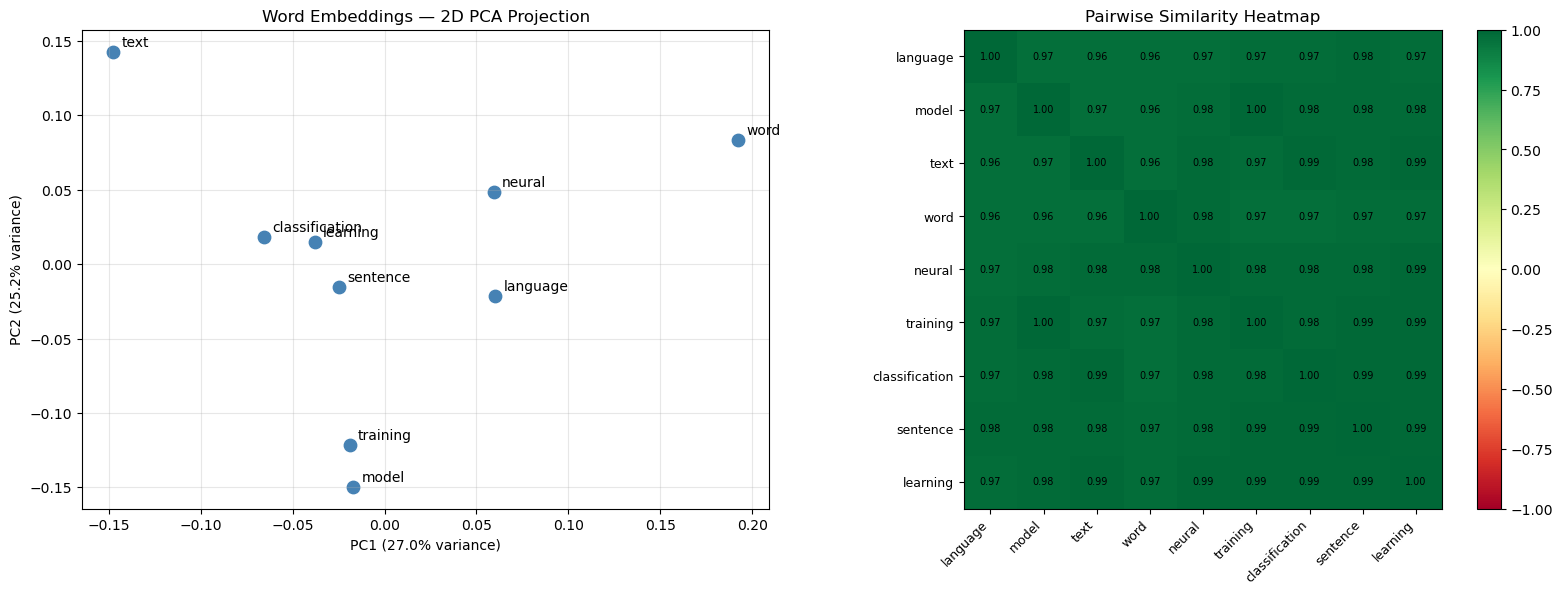

In [ ]:
vectors = np.array([model.wv[w] for w in selected_words])
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(vectors)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: 2D word positions
axes[0].scatter(reduced[:, 0], reduced[:, 1], s=80, color='steelblue')
for i, word in enumerate(selected_words):
    axes[0].annotate(word, (reduced[i, 0], reduced[i, 1]),
                     textcoords='offset points', xytext=(6, 4), fontsize=10)
axes[0].set_title('Word Embeddings — 2D PCA Projection', fontsize=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].grid(alpha=0.3)

# Plot 2: Similarity heatmap
sim_values = similarity_matrix.values.astype(float)
im = axes[1].imshow(sim_values, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(selected_words)))
axes[1].set_yticks(range(len(selected_words)))
axes[1].set_xticklabels(selected_words, rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(selected_words, fontsize=9)
for i in range(len(selected_words)):
    for j in range(len(selected_words)):
        axes[1].text(j, i, f'{sim_values[i, j]:.2f}',
                     ha='center', va='center', fontsize=7, color='black')
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Pairwise Similarity Heatmap', fontsize=12)

plt.tight_layout()
plt.show()

---
## Practical Task 3 — Comparison Report: One-Hot Encoding vs Word Embeddings

In [9]:
vocab_list = list(model.wv.key_to_index.keys())
vocab_size = len(vocab_list)

# One-hot vector for 'language'
sample_word = 'language'
word_index = vocab_list.index(sample_word)
one_hot_vector = np.zeros(vocab_size)
one_hot_vector[word_index] = 1

print(f'Vocabulary size               : {vocab_size}')
print(f'One-hot vector size           : {vocab_size} (one dim per word)')
print(f'Non-zero values               : {int(one_hot_vector.sum())} (always exactly 1)')
print(f"First 10 dims of '{sample_word}': {one_hot_vector[:10]}")
print()

embedding_vector = model.wv[sample_word]
print(f'Word2Vec vector size          : {len(embedding_vector)} (fixed regardless of vocab)')
print(f'Non-zero values               : {np.count_nonzero(embedding_vector)} / {len(embedding_vector)}')
print(f"First 10 dims of '{sample_word}': {np.round(embedding_vector[:10], 4)}")

Vocabulary size               : 129
One-hot vector size           : 129 (one dim per word)
Non-zero values               : 1 (always exactly 1)
First 10 dims of 'language': [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]

Word2Vec vector size          : 100 (fixed regardless of vocab)
Non-zero values               : 100 / 100
First 10 dims of 'language': [ 0.0985  0.0306 -0.0934  0.0005 -0.1083  0.06    0.016   0.0542 -0.1712
 -0.0415]


| Feature | One-Hot Encoding | Word Embeddings (Word2Vec) |
|---|---|---|
| **Size** | Equal to the vocabulary size. | Fixed dense dimension.|
| **Meaning Representation** | No semantic meaning. | Captures semantic meaning. |
| **Efficiency** | Sparse and memory-inefficient since most values are zeroes. | Dense and memory-efficient since all values carry learned information. |
| **Semantic Understanding** | None. | High. |